In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

In [4]:
# reading data
default_df = pd.read_csv("trajectory_data/no_connection_time_optimization_default_samples_circle_2_0_obstacle.csv")
connection_time_optimized_df = pd.read_csv("trajectory_data/default_samples_circle_2_0_obstacle.csv")
near_obstacle_df = pd.read_csv("trajectory_data/circle_obstacle_0_1m_away.csv")
fast_speed_far_obstacle_df = pd.read_csv("trajectory_data/fast_speed_far_obstacle.csv")
fast_speed_robot_obstacle_df = pd.read_csv("trajectory_data/fast_speed_robot_obstacle.csv")
start_in_obstacle_df = pd.read_csv("trajectory_data/start_in_circle_obstacle.csv")
df = pd.read_csv("/tmp/tbots/yellow_test/path_summary.csv")
df

,sub_dest_x,sub_dest_y,connection_time,duration,start_x,start_y,end_x,end_y,initial_vel(x),initial_vel(y),...,x18,y18,x19,y19,x20,y20,circle_obst_x,circle_obst_y,circle_obst_rad,total_cost
0,0.000000,0.000000,0.0,0.730298,0,0,0.4,0,0,0,...,0.392000,0.000000,0.398000,0.000000,0.4,0.000000e+00,0.2,0,0.18,5.87030
1,0.100000,0.000000,0.2,0.748362,0,0,0.4,0,0,0,...,0.391599,0.000000,0.397900,0.000000,0.4,0.000000e+00,0.2,0,0.18,5.88927
2,0.091355,0.040674,0.2,0.784822,0,0,0.4,0,0,0,...,0.392869,0.003325,0.398554,0.000831,0.4,-1.040830e-17,0.2,0,0.18,5.93164
3,0.066913,0.074315,0.2,0.854930,0,0,0.4,0,0,0,...,0.391036,0.005856,0.397759,0.001354,0.4,1.387780e-17,0.2,0,0.18,6.01792
4,0.030902,0.095106,0.2,0.947549,0,0,0.4,0,0,0,...,0.389567,0.008415,0.397412,0.002104,0.4,0.000000e+00,0.2,0,0.18,5.87192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2.007390,-2.229430,0.4,1.407230,0,0,0.4,0,0,0,...,0.410533,-0.027229,0.402319,-0.006807,0.4,-1.387780e-16,0.2,0,0.18,6.56967
123,2.007390,-2.229430,0.6,2.259580,0,0,0.4,0,0,0,...,0.443713,-0.059382,0.410928,-0.013995,0.4,0.000000e+00,0.2,0,0.18,7.42202
124,2.740640,-1.220210,0.2,0.773870,0,0,0.4,0,0,0,...,0.393365,-0.003841,0.398675,-0.000960,0.4,0.000000e+00,0.2,0,0.18,5.91987
125,2.740640,-1.220210,0.4,1.241970,0,0,0.4,0,0,0,...,0.417885,-0.012921,0.404471,-0.002819,0.4,0.000000e+00,0.2,0,0.18,6.38797


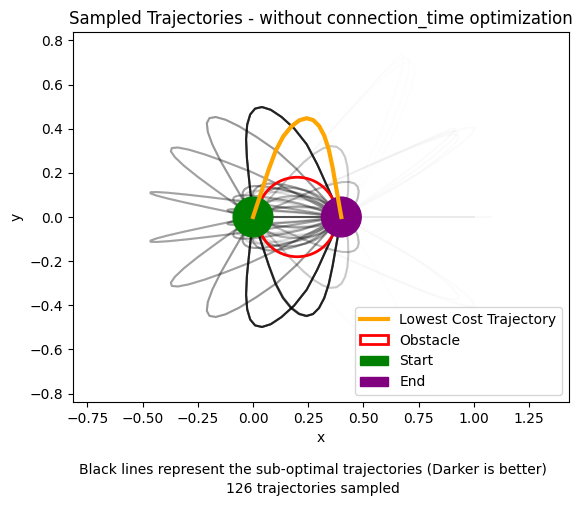

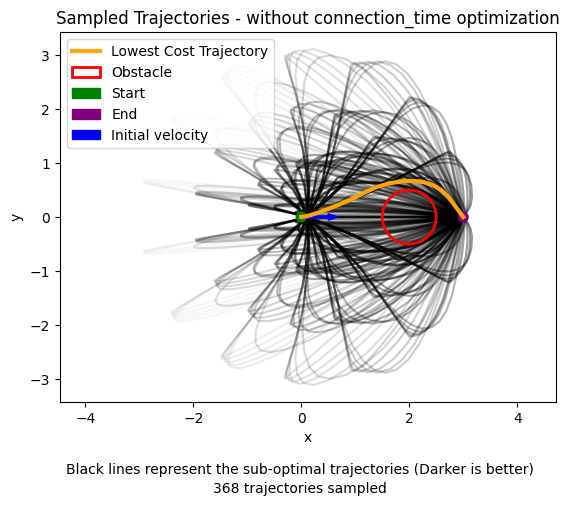

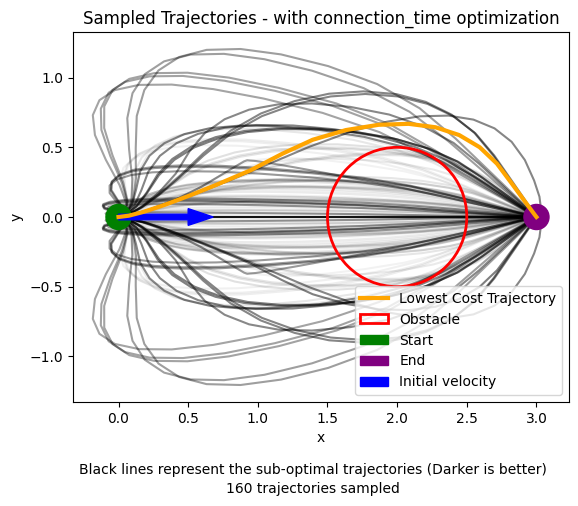

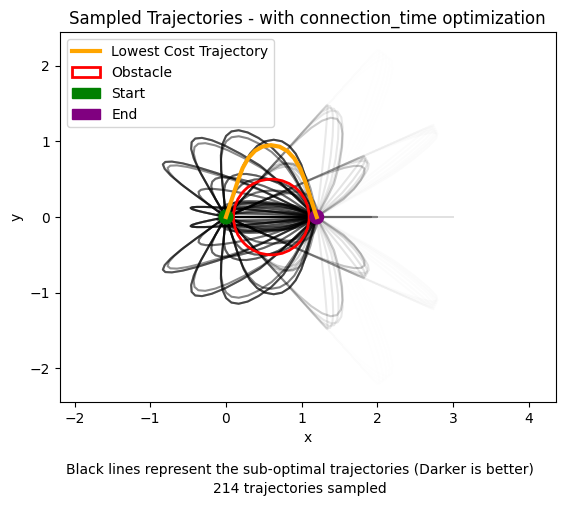

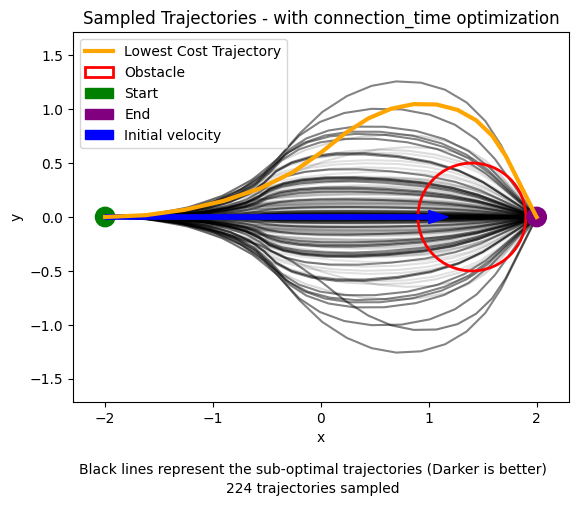

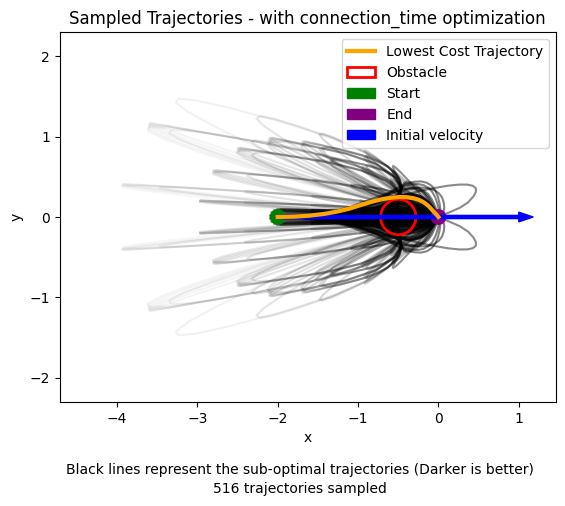

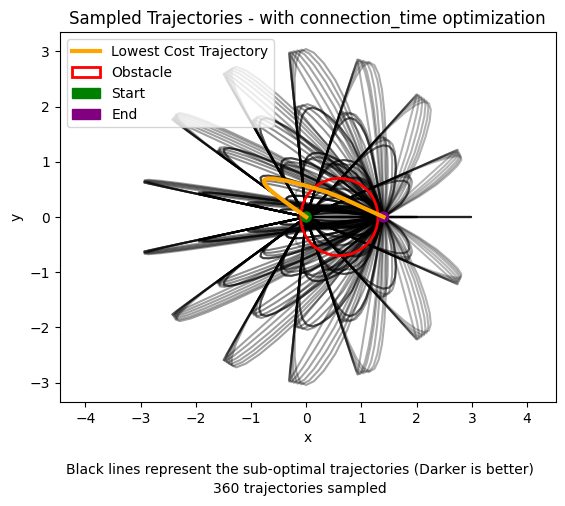

In [5]:
import matplotlib.pyplot as plt

def plot_trajectories(df, title):

    # Normalize the 'total_cost' column to [0, 1]
    df['normalized_cost'] = (df['total_cost'] - df['total_cost'].min()) / (df['total_cost'].max() - df['total_cost'].min())

    # Plot all other trajectories
    for _, row in df.iterrows():
        x_coords = [row[f'x{i}'] for i in range(21)]
        y_coords = [row[f'y{i}'] for i in range(21)]
        plt.plot(x_coords, y_coords, color='black', alpha=0.5 * (1-row['normalized_cost']), zorder=1)

    # Find the row with the lowest total cost
    min_cost_row = df.loc[df['total_cost'].idxmin()]

    # Extract the x and y coordinates of the trajectory
    x_coords_min = [min_cost_row[f'x{i}'] for i in range(21)]
    y_coords_min = [min_cost_row[f'y{i}'] for i in range(21)]

    # Plot the trajectory with the lowest cost
    plt.plot(x_coords_min, y_coords_min, label='Lowest Cost Trajectory', color='orange', linewidth=3)

    # Plot the circle obstacle
    circle = plt.Circle((min_cost_row['circle_obst_x'], min_cost_row['circle_obst_y']), min_cost_row['circle_obst_rad'], color='r', label='Obstacle', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    # Plot start and end positions
    start = plt.Circle((min_cost_row['start_x'], min_cost_row['start_y']), 0.09, color='g', label='Start', fill=True)
    end = plt.Circle((min_cost_row['end_x'], min_cost_row['end_y']), 0.09, color='purple', label='End', fill=True)
    plt.gca().add_patch(start)
    plt.gca().add_patch(end)

    # Draw a vector to represent the initial velocity
    if min_cost_row['initial_vel(x)'] != 0 or min_cost_row['initial_vel(y)'] != 0:
        plt.arrow(min_cost_row['start_x'], min_cost_row['start_y'], min_cost_row['initial_vel(x)'], min_cost_row['initial_vel(y)'], color='blue', width=0.04, label='Initial velocity')    

    plt.xlabel('x')
    plt.ylabel('y')
    # Add description text outside of the plot
    plt.figtext(0.5, -0.04, 'Black lines represent the sub-optimal trajectories (Darker is better)', ha='center')
    plt.figtext(0.5, -0.08, f'{len(df)-1} trajectories sampled', ha='center')
    plt.title(title)
    plt.legend()

    # Set equal aspect ratio
    plt.axis('equal')
    plt.show()

plot_trajectories(df, title='Sampled Trajectories - without connection_time optimization')
plot_trajectories(default_df, title='Sampled Trajectories - without connection_time optimization')
plot_trajectories(connection_time_optimized_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(near_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(fast_speed_far_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(fast_speed_robot_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(start_in_obstacle_df, title='Sampled Trajectories - with connection_time optimization')

